# Marketing Goals — **dispersion diagnostics** (exploratory)

*Lee Jerusalmy*

Isolated notebook under `experiments/cv_optimization/dispersion_diagnostics/`.

**Question:** when existing CV is high, is variability (A) tail-driven, (B) broad in the center, or (C) multiplicative / asymmetric on the original scale?

**Not** a methodology change: does not replace CV, invent 15%-style thresholds for MAD/IQR, change trimming, or modify goals.

Uses the **same** post-trim cohort `growth_ratio`s that feed `cv_after`.  
Pinned `AS_OF_DATE = 2026-08-03`. Production LS flag thr kept at **0.175**.

Separate from `cv_oos_backtest` (predictive) and from `robust_cv` (MAD×1.4826 as CV alternative).


In [1]:
# ── Auth (Google Colab) ──────────────────────────────────────────
from google.colab import auth
auth.authenticate_user()
IN_COLAB = True
print('Authenticated (Colab)')


Authenticated (Colab)


In [2]:
project_id = 'oceanic-citadel-454608-d2'
from google.cloud import bigquery
client = bigquery.Client(project=project_id)
print('BigQuery client ready for', project_id)


BigQuery client ready for oceanic-citadel-454608-d2


In [3]:
# ── Optional: mount Google Drive (to write under marketing_goals/runs/) ──
# Skip this cell if you only want browser downloads.

MOUNT_DRIVE = True  # set False to skip

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted. Expected runs path:')
    print('  /content/drive/MyDrive/lee_project/marketing_goals/runs')
    print('  (or My Drive with a space — export cell checks both)')
else:
    print('Drive mount skipped — export will browser-download CSVs only.')


Mounted at /content/drive
Drive mounted. Expected runs path:
  /content/drive/MyDrive/lee_project/marketing_goals/runs
  (or My Drive with a space — export cell checks both)


In [4]:
import pandas as pd
import numpy as np
from pandas_gbq import read_gbq

# ── Date anchor (shared for both brands) ──
# CHANGED (temporary for testing): pin AS_OF to match prior CV test runs.
# REVERT for production to: pd.Timestamp.now().normalize() - pd.Timedelta(days=2)
AS_OF_DATE = pd.Timestamp('2026-08-03')

# ── Shared patch / horizon calendar ──
PATCHES = (
    (1, 7), (7, 14), (14, 30), (30, 60), (60, 90),
    (90, 120), (120, 150), (150, 180), (180, 270), (270, 365),
)
GOAL_HORIZONS = [7, 30, 60, 90, 120, 150, 180, 210, 240, 270, 365]
CHECKPOINTS   = [7, 30, 60, 90, 120, 150, 180, 210, 240, 270, 365]
LOOKBACK_COHORTS = 35
EXPERIMENT_TAG = 'dispersion_diagnostics'  # ADDED: distinct runs/ folder

FOCUS_CASES = [
    ('lonestar', 'Blended', '1->7'),
    ('lonestar', 'Web', '1->7'),
    ('lonestar', 'Web', '180->270'),
    ('realprize', 'App', '1->7'),
    ('realprize', 'Blended', '1->7'),
    ('realprize', 'Web', '1->7'),
    ('realprize', 'Web', '7->14'),
    ('realprize', 'Web', '14->30'),
    ('realprize', 'Web', '30->60'),
]
ORGANIC_LABEL = 'Organic'

# ── Which brands to run ──
RUN_BRANDS = ['realprize', 'lonestar']

# ── Per-brand knobs (from config/*.yaml / Combined predecessors) ──
BRAND_CONFIGS = {
    'realprize': {
        'brand': 'realprize',
        'cost_table': 'analytics.realprize_cost_per_user',
        'deposits_table': 'realprize.casino_astropay_dmn',
        # TikTok excluded entirely
        'exclude_affids': [4313],
        'populations': ['Web', 'App', 'Affiliate'],
        'trim_config': {
            'App':       {'method': 'winsor', 'pct': 0},
            'Web':       {'method': 'winsor', 'pct': 0.01},
            'Affiliate': {'method': 'winsor', 'pct': 0.01},
            'Blended':   {'method': 'winsor', 'pct': 0},
        },
        'organic_trim_method': 'winsor',
        'organic_trim_pct': 0,
        # App attribution change ~2025-08-12 — pin share above this horizon
        'organic_share_cap_horizon': 120,
        'cv_threshold': 0.15,
        'cv_good_enough': 0.10,
        'max_remove_fraction': 0.15,
        # RP Combined did not use a min-cohort-dates gate (default 1)
        'min_cohort_dates': 1,
        # Tail fill only in LS predecessor
        'extrapolate_tail': False,
        'extrapolation_tail_days': 30,
        'has_scope_bucket': True,  # app / non_app + app_organic
        'users_sql': None,  # filled below via builder
    },
    'lonestar': {
        'brand': 'lonestar',
        'cost_table': 'analytics.lonestar_cost_per_user',
        'deposits_table': 'lonestar.casino_astropay_dmn',
        # TikTok + TikTok Canada
        'exclude_affids': [4866, 7127],
        'populations': ['Web', 'Affiliate'],  # add App when LS App launches
        'trim_config': {
            'Web':       {'method': 'winsor', 'pct': 0},
            'Affiliate': {'method': 'winsor', 'pct': 0.01},
            'Blended':   {'method': 'winsor', 'pct': 0},
        },
        'organic_trim_method': 'winsor',
        'organic_trim_pct': 0,
        # No organic share cap on LS
        'organic_share_cap_horizon': None,
        'cv_threshold': 0.175,
        'cv_good_enough': 0.10,
        'max_remove_fraction': 0.15,
        'min_cohort_dates': 20,
        'extrapolate_tail': True,
        'extrapolation_tail_days': 30,
        'has_scope_bucket': False,  # scope defaults to 'all' in organic helper
        'users_sql': None,
    },
}

# ── Monitoring (print sub-outputs after each pipeline step) ──
# True  = show intermediate tables in Colab after each part (recommended first runs)
# False = quieter (still prints step banners + row counts)
MONITOR_STEPS = True
MONITOR_PREVIEW_DAYS = [1, 7, 14, 30, 60, 90, 120, 180, 270, 365]
MONITOR_PREVIEW_HORIZONS = [7, 30, 120, 365]  # goals sample only

print('ENV: Google Colab')

# ── Seed Combined globals (overwritten per brand in apply_brand_globals) ──
# Helper cells use these names as defaults; they MUST exist before those cells run.
POPULATIONS = list(BRAND_CONFIGS['realprize']['populations'])  # first brand's list as placeholder
TRIM_CONFIG = dict(BRAND_CONFIGS['realprize']['trim_config'])
ORGANIC_TRIM_METHOD = BRAND_CONFIGS['realprize']['organic_trim_method']
ORGANIC_TRIM_PCT = BRAND_CONFIGS['realprize']['organic_trim_pct']
ORGANIC_SHARE_CAP_HORIZON = BRAND_CONFIGS['realprize']['organic_share_cap_horizon']
CV_THRESHOLD = BRAND_CONFIGS['realprize']['cv_threshold']
CV_GOOD_ENOUGH = BRAND_CONFIGS['realprize']['cv_good_enough']
MAX_REMOVE_FRACTION = BRAND_CONFIGS['realprize']['max_remove_fraction']
MIN_COHORT_DATES = BRAND_CONFIGS['realprize']['min_cohort_dates']
EXTRAPOLATE_TAIL = BRAND_CONFIGS['realprize']['extrapolate_tail']
EXTRAPOLATION_TAIL_DAYS = BRAND_CONFIGS['realprize']['extrapolation_tail_days']
ACTIVE_BRAND = None

print(f'Config loaded. as_of_date = {AS_OF_DATE.date()}')
print(f'Brands to run: {RUN_BRANDS}')
print(f'Monitor steps = {MONITOR_STEPS}')
print('Mode: PERSISTENT TRIM (excluded users carry forward)')
print('Main goals columns: brand, population, goal_horizon, day, raw_goal_ratio, organic_share, adjusted_goal_ratio')


ENV: Google Colab
Config loaded. as_of_date = 2026-08-03
Brands to run: ['realprize', 'lonestar']
Monitor steps = True
Mode: PERSISTENT TRIM (excluded users carry forward)
Main goals columns: brand, population, goal_horizon, day, raw_goal_ratio, organic_share, adjusted_goal_ratio


In [5]:
# ══════════════════════════════════════════════════════════════
# APPLY BRAND CONFIG → module-level globals used by helpers
# (same variable names as Combined predecessors)
# ══════════════════════════════════════════════════════════════

def apply_brand_globals(cfg: dict) -> None:
    """Set Combined-style globals for one brand before running the pipeline."""
    global POPULATIONS, TRIM_CONFIG
    global ORGANIC_TRIM_METHOD, ORGANIC_TRIM_PCT, ORGANIC_SHARE_CAP_HORIZON
    global CV_THRESHOLD, CV_GOOD_ENOUGH, MAX_REMOVE_FRACTION
    global MIN_COHORT_DATES, EXTRAPOLATE_TAIL, EXTRAPOLATION_TAIL_DAYS
    global ACTIVE_BRAND

    ACTIVE_BRAND = cfg['brand']
    POPULATIONS = list(cfg['populations'])
    TRIM_CONFIG = dict(cfg['trim_config'])
    ORGANIC_TRIM_METHOD = cfg['organic_trim_method']
    ORGANIC_TRIM_PCT = cfg['organic_trim_pct']
    ORGANIC_SHARE_CAP_HORIZON = cfg['organic_share_cap_horizon']
    CV_THRESHOLD = cfg['cv_threshold']
    CV_GOOD_ENOUGH = cfg['cv_good_enough']
    MAX_REMOVE_FRACTION = cfg['max_remove_fraction']
    MIN_COHORT_DATES = cfg['min_cohort_dates']
    EXTRAPOLATE_TAIL = cfg['extrapolate_tail']
    EXTRAPOLATION_TAIL_DAYS = cfg['extrapolation_tail_days']

    print(f"\n{'=' * 60}")
    print(f"BRAND: {ACTIVE_BRAND}")
    print(f"  populations = {POPULATIONS}")
    print(f"  CV threshold = {CV_THRESHOLD}  good_enough = {CV_GOOD_ENOUGH}")
    print(f"  min_cohort_dates = {MIN_COHORT_DATES}")
    print(f"  extrapolate_tail = {EXTRAPOLATE_TAIL}")
    print(f"  organic_share_cap_horizon = {ORGANIC_SHARE_CAP_HORIZON}")
    print(f"{'=' * 60}")


def load_brand_tables(cfg: dict, as_of_date=AS_OF_DATE):
    """Pull cost-per-user population assignment + deposit revenue for one brand."""
    sql_floor = (
        as_of_date - pd.Timedelta(days=max(GOAL_HORIZONS) + LOOKBACK_COHORTS + 5)
    ).date()
    brand = cfg['brand']
    cost_table = cfg['cost_table']
    dep_table = cfg['deposits_table']
    excl = cfg['exclude_affids']
    excl_sql = ', '.join(str(a) for a in excl)

    print(f'[{brand}] SQL floor date: {sql_floor}  (AS_OF_DATE = {as_of_date.date()})')

    if brand == 'realprize':
        # scope + bucket for App organic vs non_app organic
        users_sql = f"""
        SELECT
          id,
          CASE
            WHEN affid IN (63, 2521, 2535, 4957, 4971, 5048, 5062, 5069) THEN 'Web'
            WHEN affid = 1                                    THEN 'App'
            WHEN affid IN (64, 71)                            THEN 'PPC'
            WHEN affid IN (0, 78, 2290)                       THEN 'Organic'
            ELSE 'Affiliate'
          END AS population,
          CASE WHEN affid = 1 THEN 'app' ELSE 'non_app' END AS scope,
          CASE
            WHEN affid = 1 AND channel_type = 'app_organic' THEN 'organic'
            WHEN affid = 1                                   THEN 'acquired'
            WHEN affid IN (0, 78, 2290)                      THEN 'organic'
            ELSE 'acquired'
          END AS bucket,
          DATE(MIN(cost_date)) AS cost_date
        FROM `{cost_table}`
        WHERE cost_date >= DATE('{sql_floor}')
          AND affid NOT IN ({excl_sql})
          AND id > 0
        GROUP BY id, population, scope, bucket
        """
    elif brand == 'lonestar':
        # No scope/bucket — organic helper defaults to scope='all'
        users_sql = f"""
        SELECT
          id,
          CASE
            WHEN affid IN (63, 4432, 4551, 4698, 5048, 5125, 7120, 7253, 7260, 8331, 8345) THEN 'Web'
            -- WHEN affid = 1 THEN 'App'   -- uncomment when LS App launches
            WHEN affid IN (64, 71)  THEN 'PPC'
            WHEN affid IN (0, 78)   THEN 'Organic'
            ELSE 'Affiliate'
          END AS population,
          DATE(MIN(cost_date)) AS cost_date
        FROM `{cost_table}`
        WHERE cost_date >= DATE('{sql_floor}')
          AND affid NOT IN ({excl_sql})
          AND id > 0
        GROUP BY 1, 2
        """
    else:
        raise ValueError(f'Unknown brand: {brand}')

    revenue_sql = f"""
    SELECT
      playerId AS playerid,
      DATE(date) AS date,
      SUM(amount) / 100.0 AS amount
    FROM `{dep_table}`
    WHERE Status = 'APPROVED'
      AND date >= DATE('{sql_floor}')
    GROUP BY 1, 2
    """

    users_df = read_gbq(users_sql, project_id=project_id, use_bqstorage_api=True)
    revenue_df = read_gbq(revenue_sql, project_id=project_id, use_bqstorage_api=True)

    print(f'[{brand}] users_df:   {len(users_df):,} rows')
    print(f'[{brand}] revenue_df: {len(revenue_df):,} rows')
    print(users_df['population'].value_counts().to_string())
    return users_df, revenue_df

print('Brand loader + apply_brand_globals ready.')


Brand loader + apply_brand_globals ready.


In [6]:
# ══════════════════════════════════════════════════════════════
# HELPERS — math & base table construction
# ══════════════════════════════════════════════════════════════

def weighted_mean_std_cv(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[m], w[m]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    mu  = np.average(x, weights=w)
    var = np.average((x - mu) ** 2, weights=w)
    sd  = np.sqrt(var)
    cv  = sd / mu if mu != 0 else np.nan
    return mu, sd, cv


def build_user_revenue_cums(users_df, revenue_df, *, max_day=365):
    """
    Precompute cumulative per-user revenue indexed by (population, cost_date, user, dsi).
    Returns:
      u          — one row per (population, user) with their earliest cost_date
      daily_user — cumulative revenue at each (population, cost_date, user, dsi)
    """
    u = users_df[['id', 'population', 'cost_date']].copy()
    u['population'] = u['population'].astype(str).str.strip()
    u['cost_date']  = pd.to_datetime(u['cost_date'], errors='coerce').dt.date
    u = u.loc[pd.notna(u['cost_date'])].copy()
    u = u.groupby(['population', 'id'], as_index=False)['cost_date'].min()
    u = u.rename(columns={'id': '__uid__'})

    r = revenue_df[['playerid', 'date', 'amount']].copy()
    r['date'] = pd.to_datetime(r['date'], errors='coerce').dt.date
    r = r.loc[pd.notna(r['date'])].copy()

    rr = r.merge(u, left_on='playerid', right_on='__uid__', how='inner')
    rr['dsi'] = (pd.to_datetime(rr['date']) - pd.to_datetime(rr['cost_date'])).dt.days
    rr = rr.loc[(rr['dsi'] >= 0) & (rr['dsi'] <= (max_day - 1))].copy()

    daily_user = (
        rr.groupby(['population', 'cost_date', '__uid__', 'dsi'], observed=True)['amount']
          .sum().reset_index()
          .sort_values(['population', 'cost_date', '__uid__', 'dsi'])
    )
    daily_user['cum_amount'] = (
        daily_user.groupby(['population', 'cost_date', '__uid__'], observed=True)['amount']
                  .cumsum()
    )
    return u, daily_user


print('Math + base table helpers defined.')


Math + base table helpers defined.


In [7]:
# ══════════════════════════════════════════════════════════════
# HELPERS — trimming & cohort revenue summation
# ══════════════════════════════════════════════════════════════

def compute_winsor_caps(daily_user_cums, cohort_users, e, top_pct=0.01):
    """Cap per-user cumulative revenue at the (1-top_pct) quantile within each cohort date."""
    if top_pct <= 0:
        caps = cohort_users[['population', 'cost_date', '__uid__']].copy()
        caps['cap_e'] = np.inf
        return caps
    du = daily_user_cums.loc[daily_user_cums['dsi'] <= (e - 1)].copy()
    if du.empty:
        caps = cohort_users[['population', 'cost_date', '__uid__']].copy()
        caps['cap_e'] = np.inf
        return caps
    per_user = (
        du.groupby(['population', 'cost_date', '__uid__'], observed=True)['cum_amount']
          .max().reset_index(name='cum_e')
    )
    per_user = cohort_users.merge(per_user, on=['population', 'cost_date', '__uid__'], how='left')
    per_user['cum_e'] = per_user['cum_e'].fillna(0.0)
    per_user['cap_e'] = (
        per_user.groupby(['population', 'cost_date'], observed=True)['cum_e']
                .transform(lambda s: s[s > 0].quantile(1.0 - top_pct) if (s > 0).any() else np.inf)
    )
    return per_user[['population', 'cost_date', '__uid__', 'cap_e']]


def apply_cohort_trim(daily_user_cums, cohort_users, e, trim_pct=0.10):
    """Remove the top trim_pct of depositors (by cumulative revenue) from each cohort date."""
    du = daily_user_cums.loc[daily_user_cums['dsi'] <= (e - 1)].copy()
    if du.empty:
        return cohort_users.copy()
    per_user = (
        du.groupby(['population', 'cost_date', '__uid__'], observed=True)['cum_amount']
          .max().reset_index(name='cum_e')
    )
    per_user = cohort_users.merge(per_user, on=['population', 'cost_date', '__uid__'], how='left')
    per_user['cum_e'] = per_user['cum_e'].fillna(0.0)
    depositors = per_user.loc[per_user['cum_e'] > 0].copy()
    if depositors.empty:
        return cohort_users.copy()
    thresholds = (
        depositors.groupby(['population', 'cost_date'], observed=True)['cum_e']
                  .quantile(1.0 - trim_pct).reset_index(name='threshold')
    )
    per_user = per_user.merge(thresholds, on=['population', 'cost_date'], how='left')
    per_user['threshold'] = per_user['threshold'].fillna(np.inf)
    keep = per_user.loc[
        (per_user['cum_e'] == 0) | (per_user['cum_e'] <= per_user['threshold'])
    ][['population', 'cost_date', '__uid__']]
    return keep.copy()


def get_trimmed_cohort_and_caps(population, cohort_users, daily_user_cums, e):
    cfg = TRIM_CONFIG.get(population, {'method': 'cohort_trim', 'pct': 0.10})
    caps, trimmed = None, cohort_users
    if cfg['method'] == 'winsor':
        caps = compute_winsor_caps(daily_user_cums, cohort_users, e, top_pct=cfg['pct'])
    elif cfg['method'] == 'cohort_trim':
        trimmed = apply_cohort_trim(daily_user_cums, cohort_users, e, trim_pct=cfg['pct'])
    return trimmed, caps


def sum_cum_at_idx(daily_user_cums, *, cohort_users, idx, caps=None):
    """Sum cumulative revenue across all users in cohort_users at day index idx."""
    grp_cols = ['population', 'cost_date']
    if idx < 0:
        out = cohort_users.groupby(grp_cols, observed=True)['__uid__'].nunique().reset_index()
        out['sum_cum'] = 0.0
        return out[grp_cols + ['sum_cum']]
    du = daily_user_cums.loc[daily_user_cums['dsi'] <= idx].copy()
    if du.empty:
        out = cohort_users.groupby(grp_cols, observed=True)['__uid__'].nunique().reset_index()
        out['sum_cum'] = 0.0
        return out[grp_cols + ['sum_cum']]
    per_user = (
        du.groupby(grp_cols + ['__uid__'], observed=True)['cum_amount']
          .max().reset_index(name='cum')
    )
    per_user = cohort_users.merge(per_user, on=grp_cols + ['__uid__'], how='left')
    per_user['cum'] = per_user['cum'].fillna(0.0)
    if caps is not None:
        per_user = per_user.merge(caps, on=grp_cols + ['__uid__'], how='left')
        per_user['cap_e'] = per_user['cap_e'].fillna(np.inf)
        per_user['cum']   = np.minimum(per_user['cum'], per_user['cap_e'])
    sums = per_user.groupby(grp_cols, observed=True)['cum'].sum().reset_index(name='sum_cum')
    return sums


print('Trim + summation helpers defined.')


Trim + summation helpers defined.


In [8]:
# ══════════════════════════════════════════════════════════════
# ADAPTIVE CV ANALYSIS — persistent trim
# + DISPERSION instrumentation (same CV math; capture after-trim rows)
# ══════════════════════════════════════════════════════════════

# Accumulated during dispersion run (reset in the RUN cell)
DISP_DATE_ROWS = []


def patch_cv_adaptive(
    u_base, daily_user_cums, *,
    population, s, e, as_of_date,
    excluded_uids=None,
    lookback_cohorts=None,
    cv_threshold=None,
    cv_good_enough=None,
    max_remove_fraction=None,
    debug=True,
):
    # Resolve defaults at call time (after brand config applied)
    if lookback_cohorts is None:
        lookback_cohorts = LOOKBACK_COHORTS
    if cv_threshold is None:
        cv_threshold = CV_THRESHOLD
    if cv_good_enough is None:
        cv_good_enough = CV_GOOD_ENOUGH
    if max_remove_fraction is None:
        max_remove_fraction = MAX_REMOVE_FRACTION
    as_of_date   = pd.to_datetime(as_of_date).normalize()
    cohort_end   = (as_of_date - pd.Timedelta(days=e)).date()
    cohort_start = (as_of_date - pd.Timedelta(days=e + (lookback_cohorts - 1))).date()

    cohort_users = u_base.loc[
        (u_base['population'] == population) &
        (u_base['cost_date'] >= cohort_start) &
        (u_base['cost_date'] <= cohort_end)
    ][['population', 'cost_date', '__uid__']].copy()

    if cohort_users.empty:
        return pd.DataFrame(), {}, [], False, set()

    all_cohort_users = cohort_users.copy()
    n_users_in_cohort = int(cohort_users['__uid__'].nunique())

    if excluded_uids:
        cohort_users = cohort_users.loc[
            ~cohort_users['__uid__'].isin(excluded_uids)
        ].copy()

    n_users_after_prior = int(cohort_users['__uid__'].nunique())
    n_users_excluded_prior = n_users_in_cohort - n_users_after_prior

    if cohort_users.empty:
        return pd.DataFrame(), {}, [], False, set()

    trimmed_users, caps = get_trimmed_cohort_and_caps(
        population, cohort_users, daily_user_cums, e
    )
    n_users_pre_trim  = n_users_after_prior
    n_users_post_trim = int(trimmed_users['__uid__'].nunique())

    newly_excluded = (
        set(cohort_users['__uid__'].unique()) - set(trimmed_users['__uid__'].unique())
    )

    denom_w = (
        trimmed_users.groupby(['population', 'cost_date'], observed=True)['__uid__']
                     .nunique().reset_index(name='N_users')
    )
    sum_s = sum_cum_at_idx(
        daily_user_cums, cohort_users=trimmed_users, idx=s - 1, caps=caps
    ).rename(columns={'sum_cum': 'sum_cum_s'})
    sum_e = sum_cum_at_idx(
        daily_user_cums, cohort_users=trimmed_users, idx=e - 1, caps=caps
    ).rename(columns={'sum_cum': 'sum_cum_e'})

    sum_e_all = sum_cum_at_idx(
        daily_user_cums, cohort_users=all_cohort_users, idx=e - 1, caps=None
    ).rename(columns={'sum_cum': 'sum_cum_e_all'})
    total_rev_before_trim = float(sum_e_all['sum_cum_e_all'].sum())

    patch = (
        denom_w
        .merge(sum_s, on=['population', 'cost_date'])
        .merge(sum_e, on=['population', 'cost_date'])
    )
    patch['ARPU_s']       = patch['sum_cum_s'] / patch['N_users']
    patch['ARPU_e']       = patch['sum_cum_e'] / patch['N_users']
    patch['growth_ratio'] = np.where(
        patch['ARPU_s'] > 0, patch['ARPU_e'] / patch['ARPU_s'], np.nan
    )

    _, _, cv_before = weighted_mean_std_cv(patch['growth_ratio'].values, patch['sum_cum_s'].values)

    mu_unw = np.nanmean(patch['growth_ratio'].values)
    patch['abs_dev'] = (patch['growth_ratio'] - mu_unw).abs()
    sorted_dates  = patch.sort_values('abs_dev', ascending=False)['cost_date'].tolist()
    max_removable = max(1, int(np.floor(len(patch) * max_remove_fraction)))

    removed   = []
    remaining = patch.copy()

    for candidate in sorted_dates:
        _, _, cv_now = weighted_mean_std_cv(
            remaining['growth_ratio'].values, remaining['sum_cum_s'].values
        )
        if np.isnan(cv_now) or cv_now <= cv_good_enough:
            break
        if len(removed) >= max_removable:
            break
        removed.append(candidate)
        remaining = remaining.loc[~remaining['cost_date'].isin(removed)]

    mean_a, _, cv_after = weighted_mean_std_cv(
        remaining['growth_ratio'].values, remaining['sum_cum_s'].values
    )
    flagged = (not np.isnan(cv_after)) and (cv_after > cv_threshold)
    total_rev_after_trim = float(patch['sum_cum_e'].sum())
    cfg = TRIM_CONFIG.get(population, {})

    if debug:
        flag_tag = f'  >>> FLAGGED (cv={cv_after:.4f} > {cv_threshold})' if flagged else ''
        print(
            f'  [{population}] {s}->{e}  '
            f'cv {cv_before:.4f}->{cv_after:.4f}  '
            f'removed={len(removed)}/{len(patch)}  '
            f'excl_prior={n_users_excluded_prior:,}  '
            f'pre/post={n_users_pre_trim:,}/{n_users_post_trim:,}  '
            f'newly_excl={len(newly_excluded):,}{flag_tag}'
        )

    stats = dict(
        population              = population,
        patch                   = f'{s}->{e}',
        cohort_start            = str(cohort_start),
        cohort_end              = str(cohort_end),
        n_cohort_dates_total    = int(len(patch)),
        n_cohort_dates_kept     = int(len(remaining)),
        n_users_excluded_prior  = n_users_excluded_prior,
        n_users_pre_trim        = n_users_pre_trim,
        n_users_post_trim       = n_users_post_trim,
        n_users_dropped_by_trim = n_users_pre_trim - n_users_post_trim,
        total_rev_before_trim   = total_rev_before_trim,
        total_rev_after_trim    = total_rev_after_trim,
        cv_before               = float(cv_before) if not np.isnan(cv_before) else None,
        cv_after                = float(cv_after)  if not np.isnan(cv_after)  else None,
        mean_after              = float(mean_a)    if not np.isnan(mean_a)    else None,
        flagged                 = bool(flagged),
        removed_dates           = removed,
        trim_method             = cfg.get('method', 'none'),
        trim_pct                = cfg.get('pct', 0),
    )

    # ── DISPERSION ONLY (does not affect CV / flagged) ──
    brand = globals().get('ACTIVE_BRAND', None)
    removed_set = set(removed)
    detail = remaining[['population', 'cost_date', 'N_users', 'sum_cum_s',
                        'sum_cum_e', 'ARPU_s', 'ARPU_e', 'growth_ratio']].copy()
    detail.insert(0, 'brand', brand)
    detail.insert(2, 'patch', f'{s}->{e}')
    detail = detail.rename(columns={
        'cost_date': 'cohort_date',
        'growth_ratio': 'cohort_metric_used_for_cv',
        'N_users': 'n_users',
    })
    detail['was_removed_by_existing_trim'] = False
    # also keep removed dates for viz context
    removed_detail = patch.loc[patch['cost_date'].isin(removed_set),
                               ['population', 'cost_date', 'N_users', 'sum_cum_s',
                                'sum_cum_e', 'ARPU_s', 'ARPU_e', 'growth_ratio']].copy()
    if not removed_detail.empty:
        removed_detail.insert(0, 'brand', brand)
        removed_detail.insert(2, 'patch', f'{s}->{e}')
        removed_detail = removed_detail.rename(columns={
            'cost_date': 'cohort_date',
            'growth_ratio': 'cohort_metric_used_for_cv',
            'N_users': 'n_users',
        })
        removed_detail['was_removed_by_existing_trim'] = True
        detail = pd.concat([detail, removed_detail], ignore_index=True)
    detail['cv_before'] = float(cv_before) if not np.isnan(cv_before) else None
    detail['cv_after'] = float(cv_after) if not np.isnan(cv_after) else None
    detail['flagged'] = bool(flagged)
    detail['n_users_post_trim'] = n_users_post_trim
    DISP_DATE_ROWS.append(detail)

    return patch, stats, removed, flagged, newly_excluded


print('Adaptive CV function defined (persistent trim + dispersion instrumentation).')


Adaptive CV function defined (persistent trim + dispersion instrumentation).


In [9]:
# ══════════════════════════════════════════════════════════════
# PERSISTENT TRIM CURVE BUILDER (two-pass)
# ══════════════════════════════════════════════════════════════

def build_curve(
    u_base, daily_user_cums, *,
    population, as_of_date, debug=True,
):
    """Build ARPU curve with persistent trim — excluded users carry forward.
    Two-pass: first pass accumulates all exclusions unconditionally,
    second pass builds step ratios using frozen snapshots."""
    as_of_date = pd.to_datetime(as_of_date).normalize()

    cv_rows      = []
    effective    = []
    excluded_uids = set()

    # ── First pass: determine valid patches & accumulate exclusions ──
    for (s, e) in PATCHES:
        patch, stats, removed, flagged, newly_excluded = patch_cv_adaptive(
            u_base, daily_user_cums,
            population=population, s=s, e=e,
            as_of_date=as_of_date,
            excluded_uids=excluded_uids,
            debug=debug,
        )
        excluded_uids |= newly_excluded

        if not stats:
            continue

        min_cohort_dates = globals().get('MIN_COHORT_DATES', 1)
        if stats.get('n_cohort_dates_total', 0) < min_cohort_dates:
            if debug:
                print(f'  [{population}] {s}->{e}  insufficient data '
                      f'({stats["n_cohort_dates_total"]} < {min_cohort_dates}) — skipping')
            continue

        cv_rows.append(stats)
        effective.append({
            's': s, 'e': e,
            'removed_dates': removed,
            'excluded_snapshot': frozenset(excluded_uids),
        })

    if not effective:
        return pd.DataFrame(cv_rows), pd.DataFrame()

    if debug:
        print(f'  Total unique users excluded across all patches: {len(excluded_uids):,}')

    # ── Second pass: build step ratios using frozen snapshots ──
    step_rows = []
    for ep in effective:
        s, e      = ep['s'], ep['e']
        bad_dates = set(ep['removed_dates'])
        excl      = ep['excluded_snapshot']
        start_k   = 2 if s == 1 else (s + 1)

        cohort_end   = (as_of_date - pd.Timedelta(days=e)).date()
        cohort_start = (as_of_date - pd.Timedelta(days=e + (LOOKBACK_COHORTS - 1))).date()

        cohort_users = u_base.loc[
            (u_base['population'] == population) &
            (u_base['cost_date'] >= cohort_start) &
            (u_base['cost_date'] <= cohort_end)
        ][['population', 'cost_date', '__uid__']].copy()

        if bad_dates:
            cohort_users = cohort_users.loc[~cohort_users['cost_date'].isin(bad_dates)].copy()
        if excl:
            cohort_users = cohort_users.loc[~cohort_users['__uid__'].isin(excl)].copy()
        if cohort_users.empty:
            continue

        _, caps = get_trimmed_cohort_and_caps(population, cohort_users, daily_user_cums, e)
        denom_w = (
            cohort_users.groupby(['population', 'cost_date'], observed=True)['__uid__']
                        .nunique().reset_index(name='N_users')
        )

        for k in range(start_k, e + 1):
            sum_prev = sum_cum_at_idx(
                daily_user_cums, cohort_users=cohort_users, idx=k - 2, caps=caps
            ).rename(columns={'sum_cum': 'sum_prev'})
            sum_curr = sum_cum_at_idx(
                daily_user_cums, cohort_users=cohort_users, idx=k - 1, caps=caps
            ).rename(columns={'sum_cum': 'sum_curr'})
            tmp = (
                denom_w
                .merge(sum_prev, on=['population', 'cost_date'])
                .merge(sum_curr, on=['population', 'cost_date'])
            )
            tmp['ARPU_prev']  = tmp['sum_prev'] / tmp['N_users']
            tmp['ARPU_curr']  = tmp['sum_curr'] / tmp['N_users']
            tmp['step_ratio'] = np.where(
                tmp['ARPU_prev'] > 0, tmp['ARPU_curr'] / tmp['ARPU_prev'], np.nan
            )
            mean_step, _, _ = weighted_mean_std_cv(
                tmp['step_ratio'].values, tmp['sum_prev'].values
            )
            step_rows.append({
                'population':      population,
                'day':             int(k),
                'growth_step':     float(mean_step),
                'effective_patch': f'{s}->{e}',
            })

    if not step_rows:
        return pd.DataFrame(cv_rows), pd.DataFrame()

    step_df = pd.DataFrame(step_rows).sort_values('day').reset_index(drop=True)

    # ── Base ARPU from first effective patch ──
    first      = effective[0]
    fs, fe     = first['s'], first['e']
    excl_first = first['excluded_snapshot']
    base_end   = (as_of_date - pd.Timedelta(days=fe)).date()
    base_start = (as_of_date - pd.Timedelta(days=fe + (LOOKBACK_COHORTS - 1))).date()

    base_users = u_base.loc[
        (u_base['population'] == population) &
        (u_base['cost_date'] >= base_start) &
        (u_base['cost_date'] <= base_end)
    ][['population', 'cost_date', '__uid__']].copy()
    bad_first = set(first['removed_dates'])
    if bad_first:
        base_users = base_users.loc[~base_users['cost_date'].isin(bad_first)].copy()
    if excl_first:
        base_users = base_users.loc[~base_users['__uid__'].isin(excl_first)].copy()

    _, base_caps = get_trimmed_cohort_and_caps(population, base_users, daily_user_cums, fe)
    denom_base = (
        base_users.groupby(['population', 'cost_date'], observed=True)['__uid__']
                  .nunique().reset_index(name='N_users')
    )
    start_idx = 0 if fs == 1 else (fs - 1)
    sum_day1 = sum_cum_at_idx(
        daily_user_cums, cohort_users=base_users, idx=start_idx, caps=base_caps
    ).rename(columns={'sum_cum': 'sum_day1'})
    base = denom_base.merge(sum_day1, on=['population', 'cost_date'], how='inner')
    pooled_arpu_1 = (
        base['sum_day1'].sum() / base['N_users'].sum()
        if base['N_users'].sum() > 0 else 0.0
    )

    start_day = 1 if fs == 1 else fs
    out_rows  = [{'population': population, 'day': start_day,
                  'ARPU_nominal': float(pooled_arpu_1),
                  'growth_step':  np.nan,
                  'effective_patch': f'{fs}->{fe}'}]
    arpu = float(pooled_arpu_1)
    for _, row in step_df.iterrows():
        g = row['growth_step']
        if not np.isfinite(g):
            continue
        arpu *= float(g)
        out_rows.append({'population': population, 'day': int(row['day']),
                         'ARPU_nominal': float(arpu),
                         'growth_step':  float(g),
                         'effective_patch': row['effective_patch']})

    curve = pd.DataFrame(out_rows).sort_values('day').reset_index(drop=True)
    all_days = pd.DataFrame({'day': range(start_day, 366)})
    curve    = all_days.merge(curve, on='day', how='left')
    curve['population']      = population
    curve['effective_patch'] = curve['effective_patch'].ffill()
    curve['ARPU_nominal']    = curve['ARPU_nominal'].interpolate(
        method='linear', limit_area='inside'
    )
    curve = curve.dropna(subset=['ARPU_nominal']).reset_index(drop=True)
    curve['is_extrapolated'] = False

    return pd.DataFrame(cv_rows), curve


def extrapolate_curve_tail(curve, *, up_to_day=365, tail_days=30, debug=True):
    """Extend curve to up_to_day using geometric mean of last tail_days daily growth steps."""
    if curve.empty:
        return curve

    population    = curve['population'].iloc[0]
    last_real_day = int(curve['day'].max())
    if last_real_day >= up_to_day:
        return curve

    real = curve.loc[~curve['is_extrapolated']].sort_values('day')
    tail = real.tail(tail_days)
    if len(tail) < 2:
        if debug:
            print(f'  [{population}] Not enough tail data ({len(tail)}) to extrapolate.')
        return curve

    arpu_vals = tail['ARPU_nominal'].values
    ratios    = arpu_vals[1:] / arpu_vals[:-1]
    ratios    = ratios[np.isfinite(ratios) & (ratios > 0)]
    if len(ratios) == 0:
        return curve

    avg_daily_growth = float(np.exp(np.mean(np.log(ratios))))

    if debug:
        print(
            f'  [{population}] Extrapolating D{last_real_day + 1}→D{up_to_day}  '
            f'rate={avg_daily_growth:.6f}/day  (geom. mean of last {len(ratios)} daily ratios)'
        )

    last_arpu  = float(curve.loc[curve['day'] == last_real_day, 'ARPU_nominal'].iloc[0])
    last_patch = curve.loc[curve['day'] == last_real_day, 'effective_patch'].iloc[0]
    tag_patch  = f'{last_patch} (extrapolated)'

    new_rows = []
    arpu = last_arpu
    for d in range(last_real_day + 1, up_to_day + 1):
        arpu *= avg_daily_growth
        new_rows.append({
            'population':      population,
            'day':             d,
            'ARPU_nominal':    float(arpu),
            'growth_step':     avg_daily_growth,
            'effective_patch': tag_patch,
            'is_extrapolated': True,
        })

    return pd.concat([curve, pd.DataFrame(new_rows)], ignore_index=True)


def build_all_populations(
    u_base, daily_user_cums, *,
    as_of_date, debug=True,
    extrapolate_tail=False, tail_days=30, extrapolate_up_to=365,
):
    all_cv_rows = []
    all_curves  = []
    for pop in POPULATIONS:
        if debug:
            print(f'\n{"=" * 55}')
            print(f'POPULATION: {pop}')
            print(f'{"=" * 55}')
        cv_df, curve = build_curve(
            u_base, daily_user_cums,
            population=pop, as_of_date=as_of_date, debug=debug,
        )
        if not cv_df.empty:
            all_cv_rows.append(cv_df)
        if not curve.empty and extrapolate_tail:
            curve = extrapolate_curve_tail(
                curve, up_to_day=extrapolate_up_to, tail_days=tail_days, debug=debug,
            )
        if not curve.empty:
            all_curves.append(curve)
    cv_out    = pd.concat(all_cv_rows, ignore_index=True) if all_cv_rows else pd.DataFrame()
    curve_out = pd.concat(all_curves, ignore_index=True) if all_curves else pd.DataFrame()
    return cv_out, curve_out

print('Persistent trim curve builder defined.')


Persistent trim curve builder defined.


In [10]:
# ADDED: organic helper skipped in dispersion_diagnostics.
print('Organic helpers skipped (dispersion_diagnostics).')


Organic helpers skipped (dispersion_diagnostics).


In [11]:
# ══════════════════════════════════════════════════════════════
# PART 4 helpers — Goal construction + brand pipeline
# Per-population: adjusted = (ARPU_day / ARPU_horizon) × (1 − organic_share_at_horizon)
# Blended:        adjusted = raw_goal_ratio (no organic adjustment)
# ──
# Organic share rule: for every day inside a horizon, use the share measured AT
# the horizon endpoint (not the share at the day's nearest checkpoint).
# RP: pin lookup to min(horizon, ORGANIC_SHARE_CAP_HORIZON) when cap is set.
# LS: no cap (cap is None).
# ══════════════════════════════════════════════════════════════

def build_goals(curve_df, organic_df, populations, goal_horizons=None,
                organic_share_cap_horizon=None):
    if goal_horizons is None:
        goal_horizons = GOAL_HORIZONS

    has_scope = 'scope' in organic_df.columns
    available_scopes = set(organic_df['scope'].unique()) if has_scope else {'all'}

    org_lookup = {}
    scope_col = 'scope' if has_scope else None
    endpoint = organic_df.loc[organic_df['checkpoint_day'] == organic_df['goal_horizon']]
    if scope_col:
        for scope, grp in endpoint.groupby(scope_col):
            org_lookup[scope] = grp.set_index('goal_horizon')['organic_share_pct'].to_dict()
    else:
        org_lookup['all'] = endpoint.set_index('goal_horizon')['organic_share_pct'].to_dict()

    def pop_to_scope(pop):
        if pop == 'App' and 'app' in available_scopes:
            return 'app'
        if 'non_app' in available_scopes:
            return 'non_app'
        return next(iter(available_scopes))

    rows = []
    all_pops = list(populations) + ['Blended']

    for pop in all_pops:
        is_blended = (pop == 'Blended')

        pop_curve = curve_df.loc[curve_df['population'] == pop].copy()
        if pop_curve.empty:
            continue
        pop_curve = pop_curve.drop_duplicates(subset='day').set_index('day')

        for horizon in goal_horizons:
            if horizon not in pop_curve.index:
                print(f'[{pop}] Day {horizon} missing from curve — skipping horizon.')
                continue
            arpu_horizon = pop_curve.loc[horizon, 'ARPU_nominal']
            if not np.isfinite(arpu_horizon) or arpu_horizon == 0:
                continue

            if is_blended:
                org_share = 0.0
            else:
                scope = pop_to_scope(pop)
                if organic_share_cap_horizon is not None:
                    lookup_horizon = min(horizon, organic_share_cap_horizon)
                else:
                    lookup_horizon = horizon
                org_share = org_lookup.get(scope, {}).get(lookup_horizon, np.nan)

            for day in range(1, horizon + 1):
                if day not in pop_curve.index:
                    continue
                arpu_day  = pop_curve.loc[day, 'ARPU_nominal']
                eff_patch = pop_curve.loc[day, 'effective_patch'] if 'effective_patch' in pop_curve.columns else ''
                is_extrap = bool(pop_curve.loc[day, 'is_extrapolated']) if 'is_extrapolated' in pop_curve.columns else False
                raw_goal  = arpu_day / arpu_horizon

                if np.isfinite(org_share):
                    adj_goal = raw_goal * (1 - org_share)
                else:
                    adj_goal = np.nan

                rows.append(dict(
                    population           = pop,
                    goal_horizon         = horizon,
                    day                  = day,
                    ARPU_nominal         = float(arpu_day),
                    ARPU_at_horizon      = float(arpu_horizon),
                    raw_goal_ratio       = float(raw_goal),
                    organic_share        = float(org_share) if np.isfinite(org_share) else None,
                    adjusted_goal_ratio  = float(adj_goal)  if np.isfinite(adj_goal)  else None,
                    effective_patch      = eff_patch,
                    is_extrapolated      = is_extrap,
                ))

    return pd.DataFrame(rows)


def _banner(title: str):
    print('\n' + '─' * 60)
    print(title)
    print('─' * 60)


def monitor_show_users(brand, users_df):
    """After SQL load: population counts + date span."""
    _banner(f'[{brand}] MONITOR · DATA LOAD')
    print(f'users_df rows:   {len(users_df):,}')
    print('population counts:')
    print(users_df['population'].value_counts().to_string())
    cd = pd.to_datetime(users_df['cost_date'], errors='coerce')
    print(f"cost_date span: {cd.min().date()} → {cd.max().date()}")
    if 'scope' in users_df.columns:
        print('\nscope × bucket:')
        print(users_df.groupby(['scope', 'bucket'], observed=True).size().to_string())


def monitor_show_cv_curve(brand, stage, cv_df, curve_df, populations):
    """After ARPU curve build: CV table + milestone ARPU."""
    _banner(f'[{brand}] MONITOR · {stage}')
    if cv_df is not None and not cv_df.empty:
        display_cols = [
            'population', 'patch', 'n_dates_before', 'n_dates_after',
            'cv_before', 'cv_after', 'removed_dates',
            'total_rev_before_trim', 'total_rev_after_trim',
            'flagged', 'trim_method',
        ]
        display_cols = [c for c in display_cols if c in cv_df.columns]
        print('CV summary:')
        print(cv_df[display_cols].to_string(index=False))
        if 'flagged' in cv_df.columns:
            flagged = cv_df.loc[cv_df['flagged'] == True]
            if not flagged.empty:
                print('\n>>> FLAGGED PATCHES:')
                for _, r in flagged.iterrows():
                    patch = r['patch'] if 'patch' in r.index else '?'
                    print(f"    {r.get('population', '?')} / {patch}  CV={r.get('cv_after', float('nan')):.4f}")
            else:
                print('\nNo flagged patches in this stage.')
    else:
        print('CV summary: (empty)')

    if curve_df is not None and not curve_df.empty:
        milestones = list(MONITOR_PREVIEW_DAYS)
        for pop in populations:
            sub = curve_df.loc[curve_df['population'] == pop]
            if sub.empty:
                continue
            cols = [c for c in ['day', 'ARPU_nominal', 'effective_patch', 'is_extrapolated'] if c in sub.columns]
            ms = sub.loc[sub['day'].isin(milestones)][cols]
            print(f'\nARPU curve milestones — {pop}  (n_days={sub["day"].nunique()})')
            print(ms.to_string(index=False))
            if 'is_extrapolated' in sub.columns and sub['is_extrapolated'].any():
                n_ex = int(sub['is_extrapolated'].sum())
                last_real = int(sub.loc[~sub['is_extrapolated'], 'day'].max()) if (~sub['is_extrapolated']).any() else None
                print(f'  extrapolated days: {n_ex:,}  last real day: {last_real}')
    else:
        print('ARPU curve: (empty)')


def monitor_show_organic(brand, organic_df):
    """After organic share computation."""
    _banner(f'[{brand}] MONITOR · ORGANIC SHARE')
    if organic_df is None or organic_df.empty:
        print('organic_df: (empty)')
        return
    print(f'rows: {len(organic_df):,}')
    # endpoint only (checkpoint_day == goal_horizon) — what goals actually use
    if 'checkpoint_day' in organic_df.columns and 'goal_horizon' in organic_df.columns:
        ep = organic_df.loc[organic_df['checkpoint_day'] == organic_df['goal_horizon']].copy()
        cols = [c for c in ['scope', 'goal_horizon', 'organic_share_pct', 'users_org', 'users_acq'] if c in ep.columns]
        for scope in ep['scope'].unique() if 'scope' in ep.columns else [None]:
            sub = ep if scope is None else ep.loc[ep['scope'] == scope]
            title = f'endpoint shares — scope={scope}' if scope is not None else 'endpoint shares'
            print(f'\n{title}:')
            print(sub[cols].to_string(index=False))
    else:
        print(organic_df.head(20).to_string(index=False))


def monitor_show_goals(brand, goals_df, populations):
    """After goal construction: sample horizons × days."""
    _banner(f'[{brand}] MONITOR · GOALS')
    if goals_df is None or goals_df.empty:
        print('goals_df: (empty)')
        return
    print(f'total goal rows: {len(goals_df):,}')
    print('counts by population:')
    print(goals_df.groupby('population', observed=True).size().to_string())

    preview_days = list(MONITOR_PREVIEW_DAYS)
    preview_horizons = list(MONITOR_PREVIEW_HORIZONS)
    preview_cols = [
        c for c in [
            'population', 'goal_horizon', 'day',
            'raw_goal_ratio', 'organic_share', 'adjusted_goal_ratio',
            'ARPU_nominal', 'is_extrapolated',
        ] if c in goals_df.columns
    ]
    for pop in list(populations) + ['Blended']:
        for horizon in preview_horizons:
            sub = goals_df.loc[
                (goals_df['population'] == pop) &
                (goals_df['goal_horizon'] == horizon) &
                (goals_df['day'].isin(preview_days))
            ]
            if sub.empty:
                continue
            print(f'\n── {pop} │ horizon D{horizon} ──')
            print(sub[preview_cols].to_string(index=False))


def run_brand_pipeline(cfg, users_df, revenue_df, as_of_date=AS_OF_DATE, monitor=None):
    """Parts 1-4 for one brand. Returns dict of frames with brand column.

    monitor=True  -> print intermediate tables after every part (for Colab monitoring)
    monitor=False -> banners only
    monitor=None  -> use global MONITOR_STEPS
    """
    global POPULATIONS  # reassigned briefly for Blended pass; must be declared before first use

    if monitor is None:
        monitor = bool(globals().get('MONITOR_STEPS', True))

    apply_brand_globals(cfg)
    brand = cfg['brand']

    if monitor:
        monitor_show_users(brand, users_df)

    # ── PART 1 — per-population ARPU curves ──
    _banner(f'[{brand}] PART 1/4 — per-population ARPU curves')
    print(f'[{brand}] Building base cums + adaptive CV patches (debug lines below)...')
    u_pop, daily_pop = build_user_revenue_cums(
        users_df.loc[users_df['population'].isin(POPULATIONS)].copy(),
        revenue_df,
        max_day=365,
    )
    print(f'[{brand}] base users in ARPU pops: {len(u_pop):,}  daily_user rows: {len(daily_pop):,}')

    cv_pop_df, curve_pop_df = build_all_populations(
        u_pop, daily_pop,
        as_of_date=as_of_date,
        extrapolate_tail=EXTRAPOLATE_TAIL,
        tail_days=EXTRAPOLATION_TAIL_DAYS,
        extrapolate_up_to=365,
        debug=True,
    )
    if monitor:
        monitor_show_cv_curve(brand, 'PART 1 done — per-pop CV + curve', cv_pop_df, curve_pop_df, POPULATIONS)

    # ── PART 2 — Blended ──
    _banner(f'[{brand}] PART 2/4 — Blended ARPU curve')
    print(f'[{brand}] Building BLENDED...')
    users_blend = users_df.copy()
    users_blend['population'] = 'Blended'
    u_blend, daily_blend = build_user_revenue_cums(
        users_blend, revenue_df, max_day=365
    )
    print(f'[{brand}] blended users: {len(u_blend):,}')
    # Temporarily set POPULATIONS so build_all_populations iterates Blended only
    _BLENDED_POPS_BACKUP = list(POPULATIONS)
    POPULATIONS = ['Blended']
    try:
        cv_blend_df, curve_blend_df = build_all_populations(
            u_blend, daily_blend,
            as_of_date=as_of_date,
            extrapolate_tail=EXTRAPOLATE_TAIL,
            tail_days=EXTRAPOLATION_TAIL_DAYS,
            extrapolate_up_to=365,
            debug=True,
        )
    finally:
        POPULATIONS = _BLENDED_POPS_BACKUP

    if monitor:
        monitor_show_cv_curve(brand, 'PART 2 done — Blended CV + curve', cv_blend_df, curve_blend_df, ['Blended'])

    cv_df    = pd.concat([cv_pop_df,    cv_blend_df],    ignore_index=True)
    curve_df = pd.concat([curve_pop_df, curve_blend_df], ignore_index=True)

    # ── PART 3 — organic share ──
    _banner(f'[{brand}] PART 3/4 — organic share')
    org_label = f'{ORGANIC_TRIM_METHOD}_{round(ORGANIC_TRIM_PCT * 100):g}pct'
    org_config = [{'method': ORGANIC_TRIM_METHOD, 'pct': ORGANIC_TRIM_PCT, 'label': org_label}]
    print(f'[{brand}] Computing organic share [{org_label}] for horizons {GOAL_HORIZONS}...')
    organic_full = organic_share_cohort_progression(
        users_df, revenue_df,
        as_of_date=as_of_date,
        goal_horizons=GOAL_HORIZONS,
        checkpoints=CHECKPOINTS,
        lookback_cohorts=LOOKBACK_COHORTS,
        positive_amount_only=True,
        trim_configs=org_config,
        persistent_trim=True,
    )
    organic_df = organic_full[['scope', 'goal_horizon', 'cohort_start', 'cohort_end',
                               'checkpoint_day',
                               f'organic_share_pct_{org_label}',
                               f'users_org_{org_label}',
                               f'users_acq_{org_label}']].copy()
    organic_df = organic_df.rename(columns={
        f'organic_share_pct_{org_label}': 'organic_share_pct',
        f'users_org_{org_label}': 'users_org',
        f'users_acq_{org_label}': 'users_acq',
    })
    if monitor:
        monitor_show_organic(brand, organic_df)
    else:
        print(f'[{brand}] organic rows: {len(organic_df):,}')

    # ── PART 4 — goals ──
    _banner(f'[{brand}] PART 4/4 — goal construction')
    goals_df = build_goals(
        curve_df, organic_df, POPULATIONS,
        goal_horizons=GOAL_HORIZONS,
        organic_share_cap_horizon=ORGANIC_SHARE_CAP_HORIZON,
    )
    if monitor:
        monitor_show_goals(brand, goals_df, POPULATIONS)
    else:
        print(f'[{brand}] goals rows: {len(goals_df):,}')

    # stamp brand
    for df in (cv_df, curve_df, organic_df, goals_df):
        if not df.empty:
            df.insert(0, 'brand', brand)

    print(f'\n[{brand}] COMPLETE — goals {len(goals_df):,} | curve {len(curve_df):,} | organic {len(organic_df):,} | cv {len(cv_df):,}')
    return {
        'cv': cv_df,
        'curve': curve_df,
        'organic': organic_df,
        'goals': goals_df,
        'populations': list(cfg['populations']),
    }

print('run_brand_pipeline + monitors ready.')
print('Set MONITOR_STEPS=True in config cell to print intermediate tables after each part.')


run_brand_pipeline + monitors ready.
Set MONITOR_STEPS=True in config cell to print intermediate tables after each part.


In [12]:
# ══════════════════════════════════════════════════════════════
# DISPERSION RUN — CV observations only (no organic / goals)
# Same Part 1+2 path as Marketing Goals (per-pop + Blended).
# ══════════════════════════════════════════════════════════════

DISP_DATE_ROWS.clear()

brand_results = {}
cv_all = []

for brand_key in RUN_BRANDS:
    cfg = BRAND_CONFIGS[brand_key]
    apply_brand_globals(cfg)
    brand = cfg['brand']
    users_df, revenue_df = load_brand_tables(cfg, as_of_date=AS_OF_DATE)
    print(f'\n[{brand}] loaded users={len(users_df):,} revenue_rows={len(revenue_df):,}')

    u_pop, daily_pop = build_user_revenue_cums(
        users_df.loc[users_df['population'].isin(POPULATIONS)].copy(),
        revenue_df,
        max_day=365,
    )
    cv_pop_df, _curve_pop = build_all_populations(
        u_pop, daily_pop,
        as_of_date=AS_OF_DATE,
        extrapolate_tail=False,
        debug=True,
    )

    users_blend = users_df.copy()
    users_blend['population'] = 'Blended'
    u_blend, daily_blend = build_user_revenue_cums(users_blend, revenue_df, max_day=365)
    _BLENDED_POPS_BACKUP = list(POPULATIONS)
    POPULATIONS = ['Blended']
    try:
        cv_blend_df, _curve_blend = build_all_populations(
            u_blend, daily_blend,
            as_of_date=AS_OF_DATE,
            extrapolate_tail=False,
            debug=True,
        )
    finally:
        POPULATIONS = _BLENDED_POPS_BACKUP

    cv_brand = pd.concat(
        [x for x in [cv_pop_df, cv_blend_df] if x is not None and not x.empty],
        ignore_index=True,
    )
    if not cv_brand.empty:
        cv_brand.insert(0, 'brand', brand)
        cv_all.append(cv_brand)
    brand_results[brand_key] = {'cv': cv_brand, 'users': users_df}

cv_df = pd.concat(cv_all, ignore_index=True) if cv_all else pd.DataFrame()
date_df = pd.concat(DISP_DATE_ROWS, ignore_index=True) if DISP_DATE_ROWS else pd.DataFrame()

print('\n' + '=' * 60)
print('DISPERSION DIAGNOSTICS RUN COMPLETE')
print(f'  as_of_date     = {AS_OF_DATE.date()}')
print(f'  experiment     = {EXPERIMENT_TAG}')
print(f'  cv summary rows= {len(cv_df):,}')
print(f'  date detail    = {len(date_df):,}')
print('=' * 60)



BRAND: realprize
  populations = ['Web', 'App', 'Affiliate']
  CV threshold = 0.15  good_enough = 0.1
  min_cohort_dates = 1
  extrapolate_tail = False
  organic_share_cap_horizon = 120
[realprize] SQL floor date: 2025-06-24  (AS_OF_DATE = 2026-08-03)
Downloading: 100%|██████████|
Downloading: 100%|██████████|
[realprize] users_df:   963,186 rows
[realprize] revenue_df: 1,786,580 rows
population
App          300533
Affiliate    260741
Organic      190943
Web          127754
PPC           83215

[realprize] loaded users=963,186 revenue_rows=1,786,580

POPULATION: Web
  [Web] 1->7  cv 0.3590->0.2446  removed=5/35  excl_prior=0  pre/post=6,241/6,241  newly_excl=0  >>> FLAGGED (cv=0.2446 > 0.15)
  [Web] 7->14  cv 0.2205->0.1507  removed=5/35  excl_prior=0  pre/post=6,565/6,565  newly_excl=0  >>> FLAGGED (cv=0.1507 > 0.15)
  [Web] 14->30  cv 0.5362->0.2209  removed=5/35  excl_prior=0  pre/post=5,061/5,061  newly_excl=0  >>> FLAGGED (cv=0.2209 > 0.15)
  [Web] 30->60  cv 0.2729->0.2018  remo

=== MASTER comparison (all brand × population × patch) ===
    brand population    patch  n_cohort_dates  n_users     mean      std  cv_after   median      MAD  scaled_mad_cv  relative_mad_raw      p10      p25      p75      p90      IQR  relative_IQR  p90_p10_ratio  relative_p10_p90_spread  std_log  log_p90_p10_spread  pct_positive_for_log  skewness  existing_flagged_status  is_focus_case
 lonestar  Affiliate     1->7              30    42607 1.790769 0.250038  0.135468 1.734980 0.216260       0.184802          0.124647 1.496545 1.582682 2.016348 2.134678 0.433666      0.249954       1.426405                 0.367805 0.137869            0.355157                   1.0  0.371356                    False          False
 lonestar    Blended     1->7              30    83998 2.637609 0.601126  0.238197 2.460135 0.483260       0.291236          0.196436 1.919355 2.171248 3.138575 3.485819 0.967328      0.393201       1.816141                 0.636739 0.225608            0.596714            

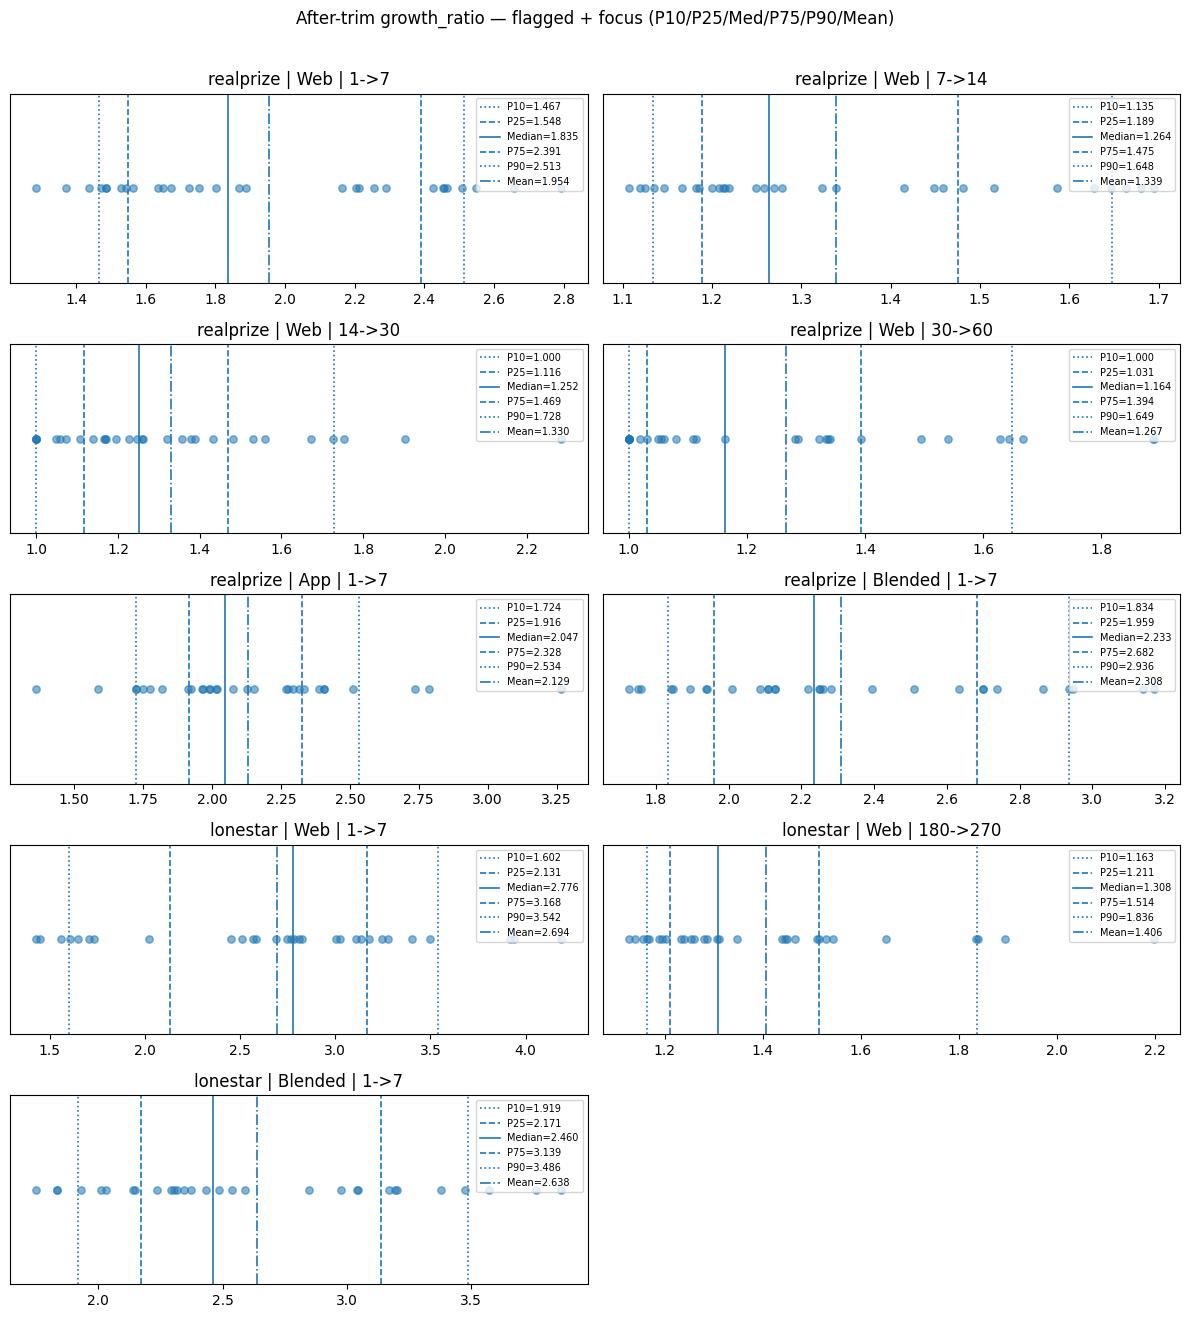

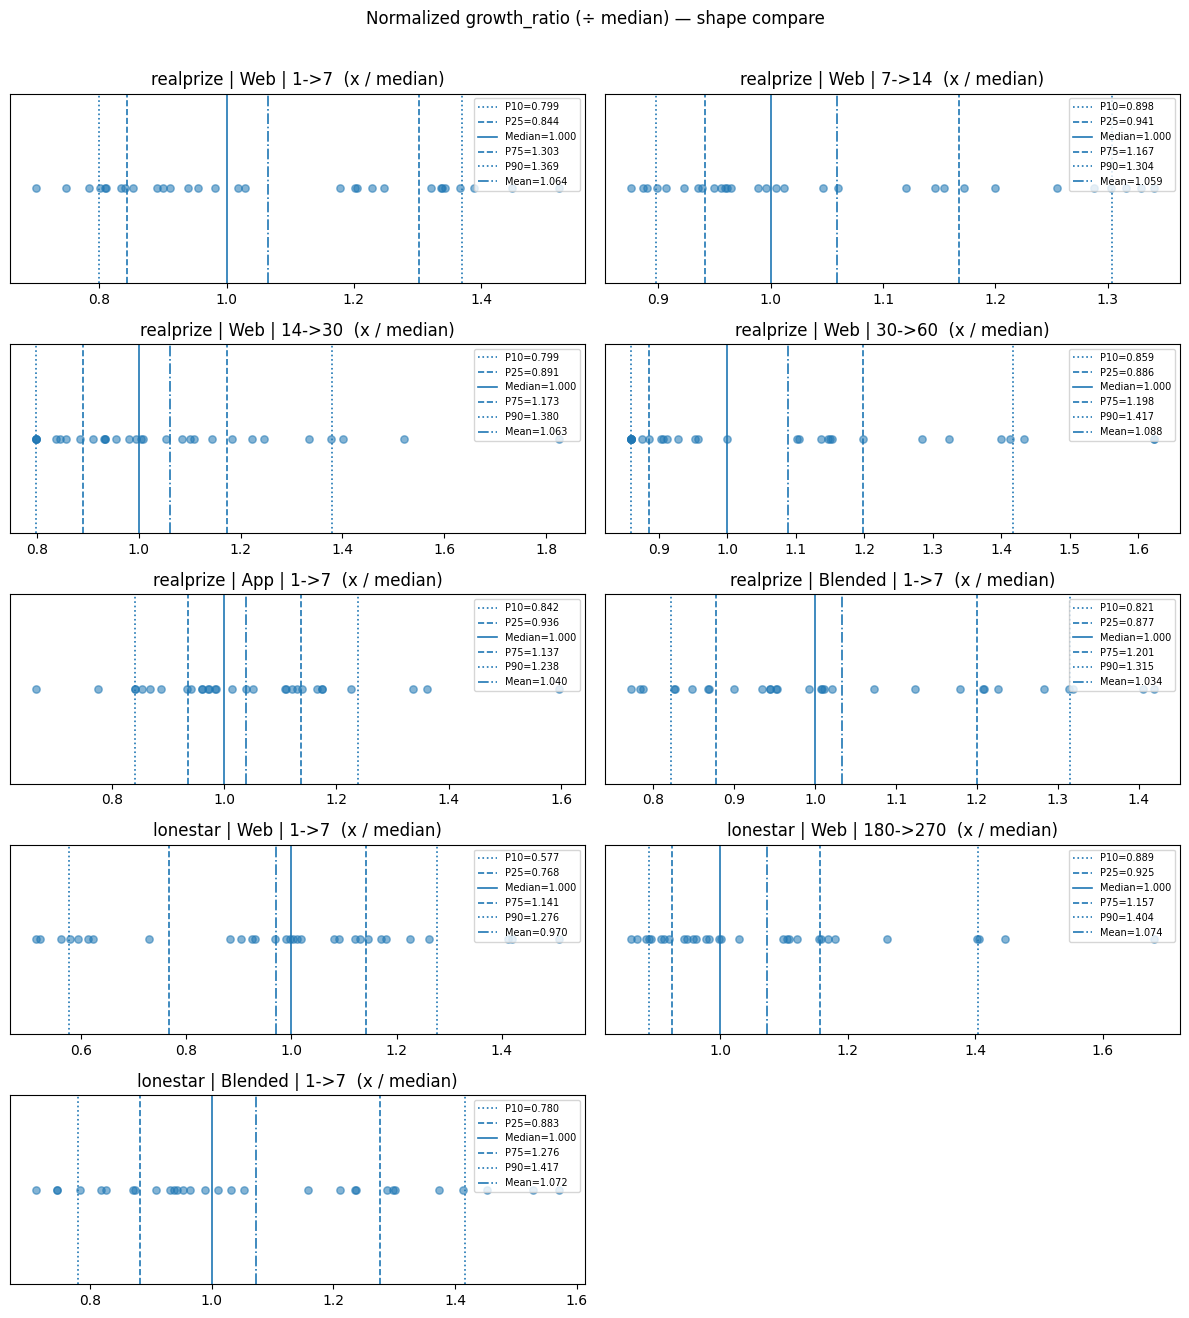

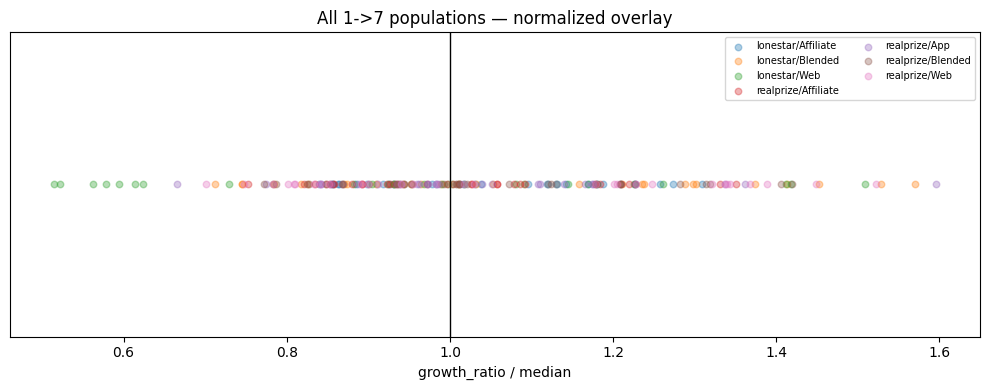

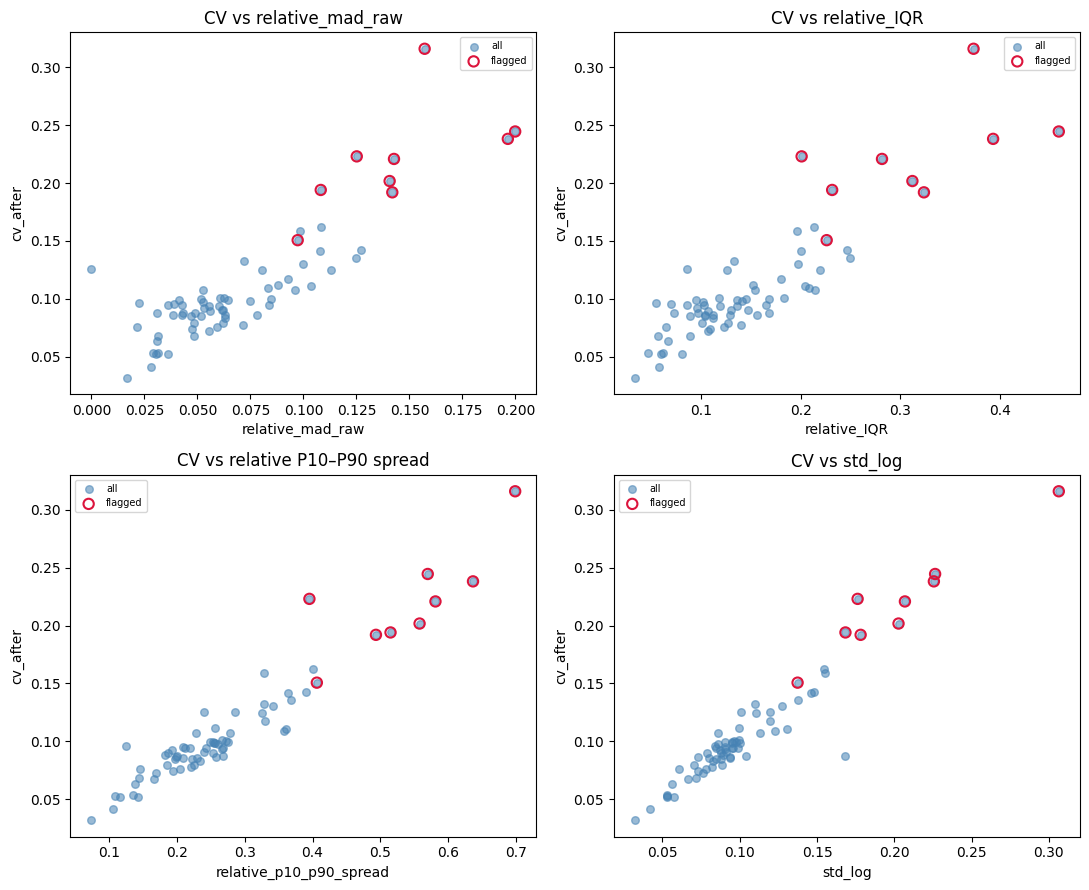

\n=== Brief answers (fill after reading tables/plots; edit as needed) ===
1. When CV is high, do MAD/IQR/P10-P90 generally confirm broad dispersion?\n   -> See flagged rows: compare cv_percentile vs riqr/rmad percentiles.\n2. Which high-CV cases appear primarily tail-driven?\n   -> Large positive tail_sensitivity_signal + lower riqr percentile.\n3. Which stay highly dispersed in the central distribution?\n   -> High cv + high riqr + high rmad percentiles together.\n4. Is 1->7 broadly dispersed centrally, or mainly tails?\n   -> See dedicated 1->7 section + normalized overlay.\n5. Does log-scale change interpretation?\n   -> Large cv_minus_log_rank; strong skew notes.\n6. Cases where CV looks high but robust center looks normal for the patch?\n   -> High tail_sensitivity_signal / cv_minus_rmad_rank.\n7. What does CV appear to measure in problematic cases?\n   -> Descriptive only from patterns above — do NOT recommend replacing CV here.
Reminder: relative_mad_raw / relative_IQR are NOT o

In [13]:
# ══════════════════════════════════════════════════════════════
# DISPERSION ANALYSIS — shape of variability (diagnostic only)
# Metrics on AFTER-trim growth_ratios (same as cv_after).
# Do NOT treat MAD/IQR/log values as "pass/fail" vs 15%.
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

assert not date_df.empty, 'date_df empty — run the DISPERSION RUN cell first'
assert not cv_df.empty, 'cv_df empty — run the DISPERSION RUN cell first'

NEAR_ZERO_MEDIAN = 1e-9  # absolute; flags invalid median denominator
FOCUS_SET = {(b, p, patch) for b, p, patch in FOCUS_CASES}

# Only observations that remain for cv_after
kept = date_df.loc[~date_df['was_removed_by_existing_trim']].copy()
kept = kept.dropna(subset=['cohort_metric_used_for_cv'])


def _safe_div(num, den):
    if den is None or not np.isfinite(den) or abs(den) <= NEAR_ZERO_MEDIAN:
        return np.nan
    return float(num / den)


def _dispersion_row(g):
    x = g['cohort_metric_used_for_cv'].astype(float).to_numpy()
    x = x[np.isfinite(x)]
    n = int(x.size)
    row = {
        'brand': g['brand'].iloc[0],
        'population': g['population'].iloc[0],
        'patch': g['patch'].iloc[0],
        'n_cohort_dates': n,
        'n_users': int(g['n_users_post_trim'].iloc[0]) if 'n_users_post_trim' in g else None,
        'cv_before': g['cv_before'].iloc[0],
        'cv_after': g['cv_after'].iloc[0],
        'existing_flagged_status': bool(g['flagged'].iloc[0]),
    }
    if n == 0:
        return row

    mean = float(np.mean(x))
    std = float(np.std(x, ddof=0))
    median_x = float(np.median(x))
    mad = float(np.median(np.abs(x - median_x)))
    q10, q25, q75, q90 = np.percentile(x, [10, 25, 75, 90])
    iqr = float(q75 - q25)
    median_ok = abs(median_x) > NEAR_ZERO_MEDIAN
    p10_ok = abs(q10) > NEAR_ZERO_MEDIAN

    pos = x[x > 0]
    pct_pos = float(pos.size / n) if n else 0.0
    if pos.size >= 2:
        log_x = np.log(pos)
        std_log = float(np.std(log_x, ddof=0))
    else:
        std_log = np.nan

    if q10 > 0 and q90 > 0:
        log_p90_p10_spread = float(np.log(q90) - np.log(q10))
        p90_p10_ratio = float(q90 / q10)
        p10_ratio_valid = True
    else:
        log_p90_p10_spread = np.nan
        p90_p10_ratio = np.nan
        p10_ratio_valid = False

    row.update({
        'mean': mean,
        'std': std,
        'median': median_x,
        'MAD': mad,
        'relative_mad_raw': _safe_div(mad, abs(median_x)) if median_ok else np.nan,
        'scaled_mad_cv': _safe_div(1.4826 * mad, abs(median_x)) if median_ok else np.nan,
        'p10': float(q10),
        'p25': float(q25),
        'p75': float(q75),
        'p90': float(q90),
        'IQR': iqr,
        'relative_IQR': _safe_div(iqr, abs(median_x)) if median_ok else np.nan,
        'p90_p10_ratio': p90_p10_ratio,
        'relative_p10_p90_spread': _safe_div(q90 - q10, abs(median_x)) if median_ok else np.nan,
        'p10_ratio_valid': p10_ratio_valid,
        'median_denominator_valid': median_ok,
        'std_log': std_log,
        'log_p90_p10_spread': log_p90_p10_spread,
        'pct_positive_for_log': pct_pos,
        'n_excluded_from_log': int(n - pos.size),
        'skewness': float(pd.Series(x).skew()) if n >= 3 else np.nan,
    })
    return row


master = pd.DataFrame([
    _dispersion_row(g) for _, g in kept.groupby(['brand', 'population', 'patch'], sort=False)
])

# Align flagged from official cv_df if needed
if 'flagged' in cv_df.columns:
    master = master.merge(
        cv_df[['brand', 'population', 'patch', 'flagged']].drop_duplicates(),
        on=['brand', 'population', 'patch'],
        how='left',
        suffixes=('', '_cv'),
    )
    master['existing_flagged_status'] = master['flagged'].fillna(master['existing_flagged_status']).astype(bool)
    master = master.drop(columns=['flagged'], errors='ignore')

master['is_focus_case'] = master.apply(
    lambda r: (r['brand'], r['population'], r['patch']) in FOCUS_SET, axis=1
)

# Within-patch percentile ranks (exploratory; not production thresholds)
rank_cols = {
    'cv_after': 'cv_percentile_within_patch',
    'relative_mad_raw': 'rmad_percentile_within_patch',
    'relative_IQR': 'riqr_percentile_within_patch',
    'relative_p10_p90_spread': 'p10_p90_percentile_within_patch',
    'std_log': 'log_dispersion_percentile_within_patch',
}
for src, dst in rank_cols.items():
    master[dst] = master.groupby('patch')[src].rank(pct=True, method='average')

master['tail_sensitivity_signal'] = (
    master['cv_percentile_within_patch'] - master['riqr_percentile_within_patch']
)
master['cv_minus_rmad_rank'] = (
    master['cv_percentile_within_patch'] - master['rmad_percentile_within_patch']
)
master['cv_minus_log_rank'] = (
    master['cv_percentile_within_patch'] - master['log_dispersion_percentile_within_patch']
)


def _interpret(r):
    """Descriptive only — relative ranks within patch, no 15% pass/fail."""
    cv = r.get('cv_after')
    flagged = bool(r.get('existing_flagged_status'))
    cv_p = r.get('cv_percentile_within_patch')
    rmad_p = r.get('rmad_percentile_within_patch')
    riqr_p = r.get('riqr_percentile_within_patch')
    log_p = r.get('log_dispersion_percentile_within_patch')
    skew = r.get('skewness')
    tail_sig = r.get('tail_sensitivity_signal')

    if cv is None or (isinstance(cv, float) and not np.isfinite(cv)):
        return 'Insufficient data.'

    notes = []
    # absolute high CV (existing flag) vs relative-to-patch
    if flagged and cv_p is not None and cv_p < 0.6:
        notes.append(
            'CV is high in absolute terms but relatively normal compared with other '
            'populations in the same maturity patch.'
        )

    if (tail_sig is not None and np.isfinite(tail_sig) and tail_sig >= 0.25
            and riqr_p is not None and riqr_p <= 0.55):
        notes.append(
            'High CV but relatively concentrated central distribution; tails appear important.'
        )
    elif (riqr_p is not None and rmad_p is not None
          and riqr_p >= 0.7 and rmad_p >= 0.7 and cv_p is not None and cv_p >= 0.7):
        notes.append(
            'High CV and high central dispersion; variability appears broad rather than tail-driven.'
        )
    elif (cv_p is not None and riqr_p is not None and rmad_p is not None
          and cv_p >= 0.7 and riqr_p >= 0.7 and rmad_p >= 0.7):
        notes.append(
            'All dispersion measures agree that this population is unusually volatile.'
        )

    if (skew is not None and np.isfinite(skew) and skew >= 1.0
            and log_p is not None and cv_p is not None
            and (cv_p - log_p) >= 0.2):
        notes.append(
            'Strong right skew; original-scale CV appears more sensitive than log-scale dispersion.'
        )
    elif (log_p is not None and cv_p is not None and (cv_p - log_p) >= 0.25):
        notes.append(
            'Original-scale CV high relative to log-scale dispersion; variability may be multiplicative / asymmetric.'
        )

    if not notes:
        if flagged:
            return 'Mixed evidence; no clear single driver.'
        return 'Distribution appears broadly stable relative to peers (or not in high-CV focus).'
    return ' '.join(notes)


master['diagnostic_interpretation'] = master.apply(_interpret, axis=1)

print('=== MASTER comparison (all brand × population × patch) ===')
master_cols = [
    'brand', 'population', 'patch', 'n_cohort_dates', 'n_users',
    'mean', 'std', 'cv_after', 'median', 'MAD', 'scaled_mad_cv', 'relative_mad_raw',
    'p10', 'p25', 'p75', 'p90', 'IQR', 'relative_IQR',
    'p90_p10_ratio', 'relative_p10_p90_spread',
    'std_log', 'log_p90_p10_spread', 'pct_positive_for_log', 'skewness',
    'existing_flagged_status', 'is_focus_case',
]
print(master[master_cols].sort_values(['patch', 'brand', 'population']).to_string(index=False))

high = master.loc[master['existing_flagged_status']].copy()
print(f'\nFlagged by existing methodology: {len(high)} / {len(master)}')

# ── Disagreement / rank table ──
print('\n=== Within-patch ranks + disagreement signals (all) ===')
rank_view = [
    'brand', 'population', 'patch', 'cv_after',
    'cv_percentile_within_patch', 'rmad_percentile_within_patch',
    'riqr_percentile_within_patch', 'p10_p90_percentile_within_patch',
    'log_dispersion_percentile_within_patch',
    'tail_sensitivity_signal', 'cv_minus_rmad_rank', 'cv_minus_log_rank',
    'existing_flagged_status',
]
print(master[rank_view].sort_values('tail_sensitivity_signal', ascending=False).to_string(index=False))

# ── Focus cases ──
print('\n=== Focus-case inspection ===')
focus = master.loc[master['is_focus_case']].copy()
print(focus[master_cols + ['tail_sensitivity_signal', 'diagnostic_interpretation']].to_string(index=False))

# ── 1->7 dedicated section ──
early = master.loc[master['patch'] == '1->7'].copy()
print('\n=== Dedicated 1->7 section ===')
early_cols = [
    'brand', 'population', 'cv_after', 'relative_mad_raw', 'relative_IQR',
    'p10', 'median', 'p90', 'p90_p10_ratio', 'std_log', 'skewness',
    'cv_percentile_within_patch', 'riqr_percentile_within_patch',
    'tail_sensitivity_signal', 'diagnostic_interpretation',
]
print(early[early_cols].sort_values('cv_after', ascending=False).to_string(index=False))
print(
    '\n1->7 read: if relative_IQR / rmad percentiles stay high with CV, '
    'central majority is also dispersed — not only tails. '
    'If tail_sensitivity_signal is large positive while riqr percentile is mid/low, '
    'CV is more tail-sensitive than the center.'
)

# ── Final high-CV diagnostic table ──
final_cols = [
    'brand', 'population', 'patch',
    'cv_after', 'cv_percentile_within_patch',
    'relative_mad_raw', 'rmad_percentile_within_patch',
    'relative_IQR', 'riqr_percentile_within_patch',
    'p10', 'median', 'p90', 'p90_p10_ratio', 'relative_p10_p90_spread',
    'std_log', 'log_dispersion_percentile_within_patch',
    'skewness', 'tail_sensitivity_signal', 'diagnostic_interpretation',
]
final = high[final_cols].sort_values('cv_after', ascending=False).copy() if not high.empty else master.loc[master['is_focus_case'], final_cols].copy()
print('\n=== FINAL diagnostic table (flagged / high-CV) ===')
print(final.to_string(index=False))

# ── Visualizations: distribution strips for flagged + focus ──
interesting = master.loc[master['existing_flagged_status'] | master['is_focus_case']].copy()
keys = list(zip(interesting['brand'], interesting['population'], interesting['patch']))

def _overlay_strip(ax, vals, title):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        ax.set_title(title + ' (empty)')
        return
    y = np.zeros_like(vals)
    ax.scatter(vals, y, alpha=0.55, s=28)
    for q, name, ls in [
        (np.percentile(vals, 10), 'P10', ':'),
        (np.percentile(vals, 25), 'P25', '--'),
        (np.median(vals), 'Median', '-'),
        (np.percentile(vals, 75), 'P75', '--'),
        (np.percentile(vals, 90), 'P90', ':'),
        (np.mean(vals), 'Mean', '-.'),
    ]:
        ax.axvline(q, linestyle=ls, linewidth=1.2, label=f'{name}={q:.3f}')
    ax.set_yticks([])
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')


n_plots = len(keys)
if n_plots:
    ncols = 2
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.6 * nrows), squeeze=False)
    for i, (b, p, patch) in enumerate(keys):
        ax = axes[i // ncols][i % ncols]
        sub = kept.loc[
            (kept['brand'] == b) & (kept['population'] == p) & (kept['patch'] == patch),
            'cohort_metric_used_for_cv',
        ]
        _overlay_strip(ax, sub.values, f'{b} | {p} | {patch}')
    for j in range(n_plots, nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle('After-trim growth_ratio — flagged + focus (P10/P25/Med/P75/P90/Mean)', y=1.01)
    plt.tight_layout()
    plt.show()

# Normalized by median
if n_plots:
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.6 * nrows), squeeze=False)
    for i, (b, p, patch) in enumerate(keys):
        ax = axes[i // ncols][i % ncols]
        sub = kept.loc[
            (kept['brand'] == b) & (kept['population'] == p) & (kept['patch'] == patch),
            'cohort_metric_used_for_cv',
        ].astype(float)
        med = np.nanmedian(sub.values)
        if med is None or not np.isfinite(med) or abs(med) <= NEAR_ZERO_MEDIAN:
            ax.set_title(f'{b} | {p} | {patch} (median invalid)')
            continue
        _overlay_strip(ax, (sub / med).values, f'{b} | {p} | {patch}  (x / median)')
    for j in range(n_plots, nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle('Normalized growth_ratio (÷ median) — shape compare', y=1.01)
    plt.tight_layout()
    plt.show()

# Combined 1->7 normalized
early_kept = kept.loc[kept['patch'] == '1->7'].copy()
if not early_kept.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    for (b, p), g in early_kept.groupby(['brand', 'population']):
        x = g['cohort_metric_used_for_cv'].astype(float).to_numpy()
        med = np.nanmedian(x)
        if not np.isfinite(med) or abs(med) <= NEAR_ZERO_MEDIAN:
            continue
        xn = x / med
        ax.scatter(xn, np.full_like(xn, 0.0), alpha=0.35, s=22, label=f'{b}/{p}')
    ax.axvline(1.0, color='black', linewidth=1)
    ax.set_yticks([])
    ax.set_xlabel('growth_ratio / median')
    ax.set_title('All 1->7 populations — normalized overlay')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

# Scatter: CV vs robust measures
scatter_pairs = [
    ('relative_mad_raw', 'CV vs relative_mad_raw'),
    ('relative_IQR', 'CV vs relative_IQR'),
    ('relative_p10_p90_spread', 'CV vs relative P10–P90 spread'),
    ('std_log', 'CV vs std_log'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (col, title) in zip(axes.ravel(), scatter_pairs):
    m = master.dropna(subset=['cv_after', col])
    ax.scatter(m[col], m['cv_after'], alpha=0.55, s=30, c='steelblue', label='all')
    f = m.loc[m['existing_flagged_status']]
    if not f.empty:
        ax.scatter(f[col], f['cv_after'], s=55, facecolors='none', edgecolors='crimson',
                   linewidths=1.5, label='flagged')
    ax.set_xlabel(col)
    ax.set_ylabel('cv_after')
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

print('\\n=== Brief answers (fill after reading tables/plots; edit as needed) ===')
_q = [
    '1. When CV is high, do MAD/IQR/P10-P90 generally confirm broad dispersion?',
    '   -> See flagged rows: compare cv_percentile vs riqr/rmad percentiles.',
    '2. Which high-CV cases appear primarily tail-driven?',
    '   -> Large positive tail_sensitivity_signal + lower riqr percentile.',
    '3. Which stay highly dispersed in the central distribution?',
    '   -> High cv + high riqr + high rmad percentiles together.',
    '4. Is 1->7 broadly dispersed centrally, or mainly tails?',
    '   -> See dedicated 1->7 section + normalized overlay.',
    '5. Does log-scale change interpretation?',
    '   -> Large cv_minus_log_rank; strong skew notes.',
    '6. Cases where CV looks high but robust center looks normal for the patch?',
    '   -> High tail_sensitivity_signal / cv_minus_rmad_rank.',
    '7. What does CV appear to measure in problematic cases?',
    '   -> Descriptive only from patterns above — do NOT recommend replacing CV here.',
]
print('\\n'.join(_q))
print(
    'Reminder: relative_mad_raw / relative_IQR are NOT on the same scale as CV=0.15. '
    'This notebook does not change Marketing Goals methodology.'
)


In [14]:
# ══════════════════════════════════════════════════════════════
# EXPORT — dispersion CSVs only (does not overwrite other experiments)
# ══════════════════════════════════════════════════════════════

from datetime import datetime
from pathlib import Path
import re

_BRAND_SLUG = {'realprize': 'rp', 'lonestar': 'ls'}
brand_slug = '_'.join(
    _BRAND_SLUG.get(b, re.sub(r'[^a-z0-9]+', '', b.lower())[:6])
    for b in RUN_BRANDS
)
exported_at = datetime.now()
run_ts = exported_at.strftime('%H%M%S')
run_tag = f"{AS_OF_DATE.date()}_{brand_slug}_{EXPERIMENT_TAG}_{run_ts}"

local_paths = {
    'cv_summary': f'combined_cv_summary_{run_tag}_dispersion.csv',
    'master': f'dispersion_master_{run_tag}.csv',
    'final': f'dispersion_final_high_cv_{run_tag}.csv',
    'dates': f'dispersion_cohort_dates_{run_tag}.csv',
}
cv_df.to_csv(local_paths['cv_summary'], index=False)
master.to_csv(local_paths['master'], index=False)
final.to_csv(local_paths['final'], index=False)
date_df.to_csv(local_paths['dates'], index=False)

print('Run tag:', run_tag)
print('Saved in working directory:')
for p in local_paths.values():
    print(' ', p)

run_candidates = [
    Path('/Users/leejerusalmy/Library/CloudStorage/'
         'GoogleDrive-lee@realplayltd.com/My Drive/lee_project/'
         'marketing_goals/runs'),
    Path('/content/drive/MyDrive/lee_project/marketing_goals/runs'),
    Path('/content/drive/My Drive/lee_project/marketing_goals/runs'),
]
drive_runs = next((c for c in run_candidates if c.is_dir()), None)
if drive_runs is not None:
    out_dir = drive_runs / run_tag
    out_dir.mkdir(parents=True, exist_ok=True)
    cv_df.to_csv(out_dir / 'combined_cv_summary_dispersion.csv', index=False)
    master.to_csv(out_dir / 'dispersion_master.csv', index=False)
    final.to_csv(out_dir / 'dispersion_final_high_cv.csv', index=False)
    date_df.to_csv(out_dir / 'dispersion_cohort_dates.csv', index=False)
    meta = pd.DataFrame([{
        'run_tag': run_tag,
        'as_of_date': str(AS_OF_DATE.date()),
        'brands': ','.join(RUN_BRANDS),
        'brand_slug': brand_slug,
        'run_ts': run_ts,
        'exported_at': exported_at.isoformat(timespec='seconds'),
        'env': 'colab',
        'experiment_tag': EXPERIMENT_TAG,
        'purpose': 'dispersion_diagnostics_only',
    }])
    meta.to_csv(out_dir / 'run_meta.csv', index=False)
    print('Saved Drive folder:', out_dir)
else:
    print('Drive runs/ folder not found — working-dir CSVs only.')


Run tag: 2026-08-03_rp_ls_dispersion_diagnostics_130742
Saved in working directory:
  combined_cv_summary_2026-08-03_rp_ls_dispersion_diagnostics_130742_dispersion.csv
  dispersion_master_2026-08-03_rp_ls_dispersion_diagnostics_130742.csv
  dispersion_final_high_cv_2026-08-03_rp_ls_dispersion_diagnostics_130742.csv
  dispersion_cohort_dates_2026-08-03_rp_ls_dispersion_diagnostics_130742.csv
Saved Drive folder: /content/drive/MyDrive/lee_project/marketing_goals/runs/2026-08-03_rp_ls_dispersion_diagnostics_130742


In [15]:
# (unused in dispersion_diagnostics)
pass
